# Category Taxonomy Investigation

Questions to answer:

- How many category as found in the products are part of the taxonomy?
- What kind of inconsistencies can be identified? And how can they be fixed?

In [1]:
from openfoodfacts.taxonomy import get_taxonomy, Taxonomy
import networkx as nx
import pandas as pd

## Load Dataset

Using a prepared dataset that was extracted from JSON-L export. Also includes Nutri-Score and number of scans.

In [2]:
file_path = "../data/off_scans_dd.csv.gz"
df = pd.read_csv(file_path, dtype={'code':str})
df = df[df.code.notna()].set_index('code') # exclude empty barcodes

# split comma separated lists
for col in ['categories_tags', 'countries_tags']:
    df[col] = df[col].str.split(',')

# use Int64 for counts with NaN
for col in ['scans_n', 'unique_scans_n']:
    df[col] = df[col].astype('Int64')

display(df)

,product_name,categories_tags,countries_tags,nutriscore_grade,scans_n,unique_scans_n
code,,,,,,
0000101209159,Véritable pâte à tartiner noisettes chocolat noir,"[en:breakfasts, en:spreads, en:sweet-spreads, ...",[en:france],e,1,1
0000105000011,Chamomile Herbal Tea,[en:null],[en:united-states],unknown,2,1
0000105000042,"Lagg's, herbal tea, peppermint","[en:plant-based-foods-and-beverages, en:bevera...",[en:united-states],unknown,<NA>,<NA>
0000105000059,Linden Flowers Tea,"[en:beverages-and-beverages-preparations, en:p...",[en:united-states],unknown,<NA>,<NA>
0000105000073,"Herbal Tea, Hibiscus",NaN,[en:united-states],unknown,<NA>,<NA>
...,...,...,...,...,...,...
55940115,NaN,NaN,[en:france],NaN,<NA>,<NA>
8797790833636,NaN,"[en:plant-based-foods-and-beverages, en:plant-...",[en:france],a,<NA>,<NA>
0170111061716,Salted Caramel protein bar,NaN,[en:netherlands],unknown,<NA>,<NA>


### Count Categories

In [3]:
#cat_counts = df.dropna(subset=['categories_tags', 'unique_scans_n']).loc[lambda x: x.unique_scans_n >= 1].categories_tags.explode().value_counts()
cat_counts = df.dropna(subset=['categories_tags']).categories_tags.explode().value_counts()
cat_counts

categories_tags
en:plant-based-foods-and-beverages                        491896
en:plant-based-foods                                      428433
en:snacks                                                 296190
en:sweet-snacks                                           218501
en:beverages                                              201701
                                                           ...  
en:i̇cecream                                                   1
en:beef-vegetable-stew-with-beetroot-and-white-cabbage         1
en:enthalt-alkohol                                             1
en:traditional-lebanese-flat-bread                             1
en:leinol-nativ                                                1
Name: count, Length: 76466, dtype: int64

## Load Category Taxonomy

Loads the most recent category taxonomy to determine category relationship.

In [4]:
categories: Taxonomy = get_taxonomy("category", download_newer=True)
print(f"categories: {len(categories):,}")

categories: 14,180


### Some examples for checking taxonomy entries

In [5]:
# all categories containing 'gherkin'
[c for c in categories.nodes if 'gherkin' in c]

['en:gherkins-pickled-in-brine',
 'en:gherkins-in-sweet-and-sour-sauce',
 'en:gherkins',
 'en:gherkins-slices',
 'en:gherkins-with-onions',
 'en:fine-gherkins',
 'en:semi-fine-gherkins',
 'en:extra-fine-gherkins',
 'en:gherkins-with-espelette-pepper',
 'en:gherkins-pickled-in-vinegar',
 'en:pickled-gherkins']

In [6]:
# all children of 'en:cucumbers'
categories['en:cucumbers'].children

[<TaxonomyNode en:small-cucumbers>, <TaxonomyNode en:fresh-cucumbers>]

# Analyze Taxonomized Categories

In [7]:
# how many categories are found in the taxonomy?
taxonomized = cat_counts.index.map(lambda x: x in categories)
taxonomized.value_counts()

categories_tags
False    67561
True      8905
Name: count, dtype: int64

### Issues

#### Bogus categories not in taxonomy -> should be removed
- 67,356 - en:groceries
- 35,228 - en:undefined
-  1,211 - en:null
-  7,254 - en:toppings-ingredients -> likely custom label for stuff to put on a pizza/meal

#### Renamed categories
- en:salted-snacks -> en:salty-snacks
  - en:salty-snacks                 37349
  - en:salted-snacks                 6275
- en:salads -> en:prepared-salads
  - en:salads                        5126
  - en:prepared-salads               3963
- en:dairy-spread -> en:dairy-spreads
  - en:dairy-spreads                 5280
  - en:dairy-spread                     6

#### renamed but kept as 2nd category name - (lacks unique category id) - note that primary name is less frequent
- en:squeezed-juices -> en:squeezed-fruit-juices
  - en:squeezed-juices               2890
  - en:squeezed-fruit-juices         1002
- en:bars-covered-with-chocolate -> en:candy-chocolate-bars
  - en:bars-covered-with-chocolate   1669
  - en:candy-chocolate-bars          1580
- en:drinkable-yogurts -> en:yogurts-drinks
  - en:drinkable-yogurts             1661
  - en:yogurt-drinks                  773
- en:raw-cured-ham -> en:dried-hams
  - en:dried-hams                    3914
  - en:raw-cured-ham                 2082

#### Remodeled Hierarchy
- en:pickled-gherkins -> en:gherkins
  - en:gherkins                      1737
  - en:pickled-gherkins               423
- en:milks-liquid-and-powder -> en:milks
  - en:milk-powders                   454
  - en:milks                          417


In [8]:
# what is not in the taxonomy?
cat_counts.loc[~taxonomized].head(20)

categories_tags
en:groceries                                67356
en:undefined                                35228
en:toppings-ingredients                      7254
en:salted-snacks                             6275
en:salads                                    5126
en:entrees                                   3880
en:squeezed-juices                           2890
en:baking-decorations                        2521
en:appetizers-sides                          2494
en:labeled-cheeses                           2105
en:aoc-cheeses                               2084
en:raw-cured-ham                             2082
en:bars-covered-with-chocolate               1669
en:drinkable-yogurts                         1661
en:null                                      1211
en:baked-goods                               1171
en:preparations-made-from-fish-meat          1140
en:pflanzliche-lebensmittel-und-getranke      945
en:mexican-dinner-mixes                       938
en:bilberries-jams                

In [9]:
# checking products with specific category
name='pasteur'
has_cat = df[df.categories_tags.apply(lambda x: any(name in c for c in x) if isinstance(x, list) else False)]
counts = has_cat.categories_tags.explode().value_counts()#.loc[lambda x: x.index.str.contains('gherkins')]
counts.head(25)

categories_tags
en:dairies                          6736
en:fermented-milk-products          4546
en:fermented-foods                  4546
en:cheeses                          4505
en:pasteurized-cheeses              3184
en:cow-cheeses                      2786
en:pasteurised-products             2299
en:milks                            1951
en:french-cheeses                   1718
en:milks-liquid-and-powder          1535
en:homogenized-milks                1410
en:uht-milks                        1319
en:unpasteurised-cheeses            1290
en:soft-cheeses                     1042
en:soft-cheeses-with-bloomy-rind     990
en:semi-skimmed-milks                673
en:pasteurised-milks                 657
en:fresh-foods                       641
en:whole-milks                       620
en:camemberts                        569
en:spreads                           547
en:cow-camemberts                    517
en:industrial-cheese                 432
en:goat-cheeses                      412


## Functions to create a graph plot

In [10]:
import pydot
from networkx.drawing.nx_pydot import to_pydot
from IPython.display import Image

def get_hierarchy(names: list) -> set:
    """Get the hierarchy of categories for a list of category names."""
    cats = [categories[name] for name in names if name in categories]
    nodes = [node for c in cats for node in c.get_parents_hierarchy()]
    return set([*cats, *nodes])

def create_graph(nodes):
  """Create a directed graph from a list of taxonomy nodes."""
  G = nx.DiGraph();

  for node in nodes:
    for parent in node.parents:
      G.add_edge(parent.id.replace(':', '.'), node.id.replace(':', '.'))
  return G

def add_labels(G):
  """Add labels to the graph nodes based on category counts."""
  for node_id in G.nodes:
    name = node_id.replace('.', ':')

    if not name in cat_counts.index:
      print(f"node '{name}' not found in df")
      continue
    count = cat_counts.loc[name]
    G.nodes[node_id]['label'] = f"{name}\n({count:,})"

def plot_graph(G, node_sep=0.8, rank_sep=0.5):
  """Plot the graph using PyDot with specific layout settings."""
  P = to_pydot(G)

  # Identify root nodes (no incoming edges)
  roots = [n for n in G.nodes if G.in_degree(n) == 0]

  # Create a subgraph for same-rank roots
  same_rank_subgraph = pydot.Subgraph(rank='same')
  for root in roots:
      node = P.get_node(root)[0]
      same_rank_subgraph.add_node(node)

  # Inject the subgraph into the pydot graph
  P.add_subgraph(same_rank_subgraph)

  P.set('rankdir', 'LR') # left to right
  P.set('nodesep', node_sep)
  P.set('ranksep', rank_sep)

  for node in P.get_nodes():
      node.set_fontname('Arial')
      node.set_shape('box')
      node.set_height(0) # remove top/bottom padding
      node.set_fontsize(11)
      node.set_style("filled")
      node.set_fillcolor("white")

  return P

# Analyze Selected Categories

## Gherkins (incl. Pickled Gherkins)

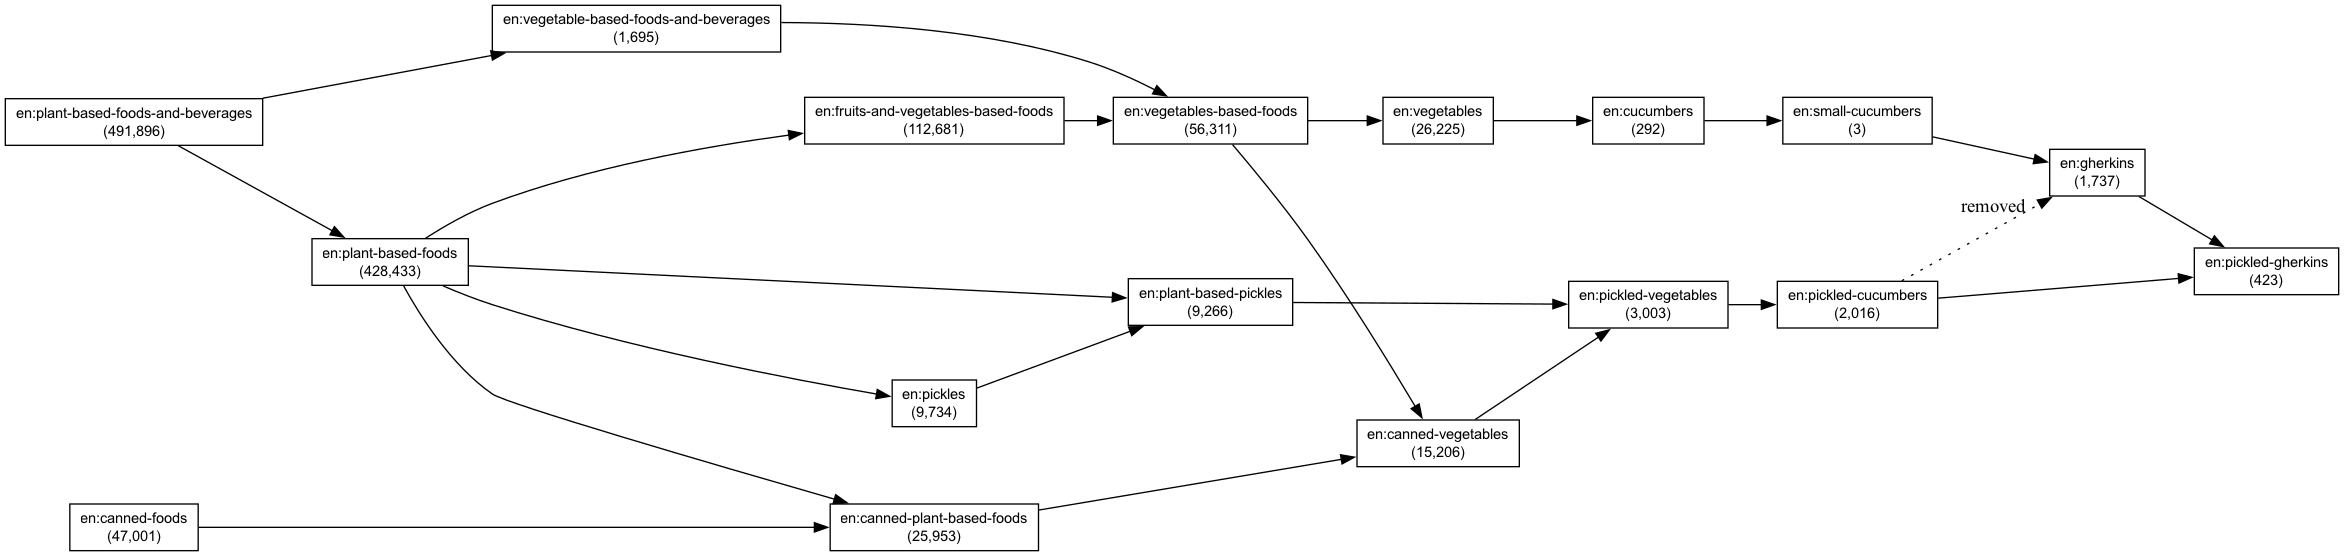

In [11]:
nodes = get_hierarchy(['en:pickled-gherkins'])
G = create_graph(nodes)

# show 'removed' relation between gherkins and pickled cucumbers
G.add_edge('en.pickled-cucumbers', 'en.gherkins', style='dotted', label='removed')

add_labels(G)

P = plot_graph(G)
P.write_png('../plots/cat_tax_gherkins_graph.png')

Image(P.create_png())

#### Investigate products with gherkin categories

Veryfies the assumption that gherkins is mostly used for pickled gherkins.

In [12]:
df['categories'] = df.categories_tags.apply(lambda x: [c for c in x if 'gherkin' in c] if isinstance(x, list) else None)
df.dropna(subset=['categories']).loc[lambda x: x['categories'].apply(lambda g: isinstance(g, list) and len(g) >= 1)][['product_name', 'categories']].head(20)

,product_name,categories
code,,
0009300000802,Kosher Dill Spears,[en:gherkins]
0009300003346,Petite Snack Crunchers,"[en:gherkins, en:pickled-gherkins]"
0031500009170,Pickles Kosher Whole Dills,[en:gherkins]
0043646954122,Gherkins with caramelized onions,"[en:gherkins, en:pickled-gherkins]"
0054100004109,Kosher Dill Gherkins,"[en:gherkins, en:pickled-gherkins]"
0059000007540,Cornichons Sûrs,[en:gherkins]
0060383674519,Petits cornichons à l'aneth,[en:gherkins]
01342444,Pfeffergurken,[en:gherkins]
0209575001768,Cornichons,[en:gherkins]


---

### Milks

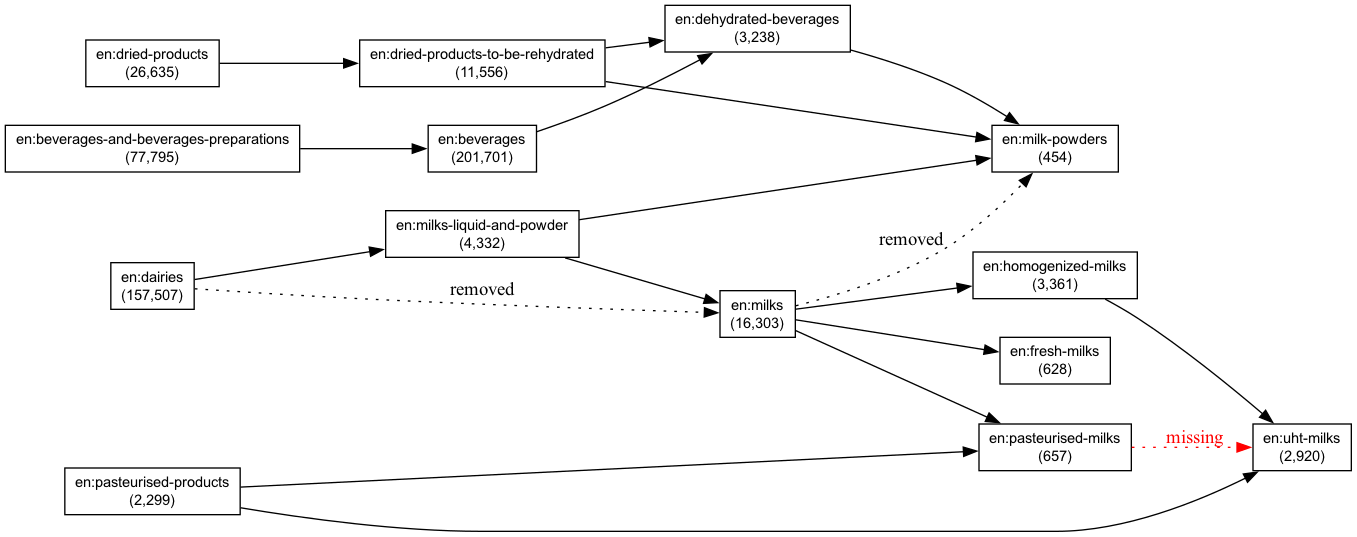

In [13]:
nodes = get_hierarchy(['en:pasteurised-milks', 'en:milk-powders', 'en:uht-milks', 'en:fresh-milks'])
G = create_graph(nodes)

# show 'removed' relations
G.add_edge('en.dairies', 'en.milks', style='dotted', label='removed')
G.add_edge('en.milks', 'en.milk-powders', style='dotted', label='removed')

# add invisible edge for missing relations
G.add_edge('en.pasteurised-milks', 'en.uht-milks', style='dotted', label='missing', color='red', fontcolor='red')

add_labels(G)
P = plot_graph(G, node_sep=0.4, rank_sep=0.6)
P.write_png('../plots/cat_tax_milks_graph.png')
Image(P.create_png())